# **Project Name** - PhonePe Transaction Insights

##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Keshika Swetha D

# **Project Summary -**


PhonePe is one of India's leading digital payment platforms, processing billions of transactions across states, districts, and pin codes every quarter. This project performs an Exploratory Data Analysis (EDA) on the PhonePe Pulse dataset, which contains transaction, user, and insurance data from 2018 to 2024.

The dataset was extracted from the official PhonePe Pulse GitHub repository, parsed from JSON format, and loaded into a structured SQLite database with 9 tables covering aggregated, map-level, and top-performer data.

The analysis focuses on five key business case studies: (1) Transaction Dynamics — understanding how different payment types perform across time and regions; (2) Market Expansion — identifying high-growth and underserved states; (3) User Engagement — measuring how actively users interact with the app; (4) Top States and Districts — pinpointing geographic leaders in transaction volume and value; and (5) User Registration — finding the most active regions for onboarding new users.

Using Python libraries including Pandas, Matplotlib, and Seaborn, this EDA uncovers patterns in transaction growth (from 806M in 2018 Q1 to 169B in 2024 Q4), identifies Merchant Payments as the dominant category, highlights Karnataka's Bengaluru Urban as the top district, and reveals that small northeastern states like Meghalaya show surprisingly high user engagement rates despite low absolute numbers. These insights provide actionable intelligence for marketing, product, and expansion strategies.


# **GitHub Link -**

https://github.com/DKSwetha/PhonePe-Transaction-Insights

# **Problem Statement**


With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and insurance-related data is crucial for improving services and targeting users effectively. This project aims to analyze and visualize aggregated values of payment categories, create maps for total values at state and district levels, and identify top-performing states, districts, and pin codes.


#### **Define Your Business Objective?**


The business objective is to derive actionable insights from PhonePe's transaction, user, and insurance data to:
1. Identify high-growth and underserved markets for strategic expansion
2. Understand user engagement patterns to improve retention
3. Analyze payment category trends to guide product development
4. Pinpoint top-performing geographies for targeted marketing campaigns


# **General Guidelines**

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("All libraries imported successfully!")


All libraries imported successfully!


### Dataset Loading

In [3]:
# Load Dataset — connect to SQLite and load all 9 tables
conn = sqlite3.connect("phonepe.db")

agg_txn  = pd.read_sql("SELECT * FROM aggregated_transaction", conn)
agg_user = pd.read_sql("SELECT * FROM aggregated_user", conn)
agg_ins  = pd.read_sql("SELECT * FROM aggregated_insurance", conn)

map_txn  = pd.read_sql("SELECT * FROM map_transaction", conn)
map_user = pd.read_sql("SELECT * FROM map_user", conn)
map_ins  = pd.read_sql("SELECT * FROM map_insurance", conn)

top_txn  = pd.read_sql("SELECT * FROM top_transaction", conn)
top_user = pd.read_sql("SELECT * FROM top_user", conn)
top_ins  = pd.read_sql("SELECT * FROM top_insurance", conn)

conn.close()
print("All 9 tables loaded successfully!")


All 9 tables loaded successfully!


### Dataset First View

In [4]:
# Dataset First Look
print("=== aggregated_transaction ===")
print(agg_txn.head(3))
print("\n=== aggregated_user ===")
print(agg_user.head(3))
print("\n=== map_transaction ===")
print(map_txn.head(3))
print("\n=== top_transaction ===")
print(top_txn.head(3))


=== aggregated_transaction ===
   id                      state  year  quarter          transaction_type  \
0   1  andaman-&-nicobar-islands  2018        1  Recharge & bill payments   
1   2  andaman-&-nicobar-islands  2018        1     Peer-to-peer payments   
2   3  andaman-&-nicobar-islands  2018        1         Merchant payments   

   transaction_count  transaction_amount  
0               4200        1.845307e+06  
1               1871        1.213866e+07  
2                298        4.525072e+05  

=== aggregated_user ===
   id                      state  year  quarter  registered_users  app_opens
0   1  andaman-&-nicobar-islands  2018        1              6740          0
1   2  andaman-&-nicobar-islands  2018        2              9405          0
2   3  andaman-&-nicobar-islands  2018        3             12149          0

=== map_transaction ===
   id                      state  year  quarter  \
0   1  andaman-&-nicobar-islands  2018        1   
1   2  andaman-&-nicobar-isl

### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
tables = {
    'aggregated_transaction': agg_txn,
    'aggregated_user': agg_user,
    'aggregated_insurance': agg_ins,
    'map_transaction': map_txn,
    'map_user': map_user,
    'map_insurance': map_ins,
    'top_transaction': top_txn,
    'top_user': top_user,
    'top_insurance': top_ins,
}

print(f"{'Table':<35} {'Rows':>8} {'Columns':>10}")
print("-" * 55)
total = 0
for name, df in tables.items():
    print(f"{name:<35} {df.shape[0]:>8,} {df.shape[1]:>10}")
    total += df.shape[0]
print("-" * 55)
print(f"{'TOTAL ROWS':<35} {total:>8,}")


Table                                   Rows    Columns
-------------------------------------------------------
aggregated_transaction                40,272          7
aggregated_user                        8,064          6
aggregated_insurance                   5,456          7
map_transaction                      164,832          7
map_user                             164,864          7
map_insurance                        111,008          7
top_transaction                      146,360          8
top_user                             146,368          7
top_insurance                         61,380          8
-------------------------------------------------------
TOTAL ROWS                           848,604


### Dataset Information

In [6]:
# Dataset Info — check dtypes and nulls
for name, df in tables.items():
    print(f"\n=== {name} ===")
    print(df.info())



=== aggregated_transaction ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  40272 non-null  int64  
 1   state               40272 non-null  object 
 2   year                40272 non-null  int64  
 3   quarter             40272 non-null  int64  
 4   transaction_type    40272 non-null  object 
 5   transaction_count   40272 non-null  int64  
 6   transaction_amount  40272 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 2.2+ MB
None

=== aggregated_user ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                8064 non-null   int64 
 1   state             8064 non-null   object
 2   year              8064 non-null 

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print(f"{'Table':<35} {'Duplicates':>12}")
print("-" * 50)
for name, df in tables.items():
    dupes = df.duplicated().sum()
    print(f"{name:<35} {dupes:>12,}")


Table                                 Duplicates
--------------------------------------------------
aggregated_transaction                         0
aggregated_user                                0
aggregated_insurance                           0
map_transaction                                0
map_user                                       0
map_insurance                                  0
top_transaction                                0
top_user                                       0
top_insurance                                  0


#### Missing Values/Null Values

In [34]:
# Missing Values/Null Values Count
print(f"{'Table':<35} {'Missing Values':>15}")
print("-" * 52)
for name, df in tables.items():
    nulls = df.isnull().sum().sum()
    print(f"{name:<35} {nulls:>15,}")


Table                                Missing Values
----------------------------------------------------
aggregated_transaction                            0
aggregated_user                                   0
aggregated_insurance                              0
map_transaction                                   0
map_user                                          0
map_insurance                                     0
top_transaction                                  16
top_user                                          0
top_insurance                                    15


In [37]:
# Check which columns have missing values
print("=== top_transaction missing values ===")
print(top_txn.isnull().sum())

print("\n=== top_insurance missing values ===")
print(top_ins.isnull().sum())

# See the actual rows with missing values
print("\n=== top_transaction null rows ===")
print(top_txn[top_txn.isnull().any(axis=1)])

print("\n=== top_insurance null rows ===")
print(top_ins[top_ins.isnull().any(axis=1)])

=== top_transaction missing values ===
id                     0
state                  0
year                   0
quarter                0
entity_type            0
entity_name           16
transaction_count      0
transaction_amount     0
amount_cr              0
dtype: int64

=== top_insurance missing values ===
id                   0
state                0
year                 0
quarter              0
entity_type          0
entity_name         15
insurance_count      0
insurance_amount     0
dtype: int64

=== top_transaction null rows ===
            id   state  year  quarter entity_type entity_name  \
8718      8719  ladakh  2019        4     pincode        None   
8768      8769  ladakh  2020        4     pincode        None   
27013    27014  ladakh  2019        4     pincode        None   
27063    27064  ladakh  2020        4     pincode        None   
45308    45309  ladakh  2019        4     pincode        None   
45358    45359  ladakh  2020        4     pincode        None  

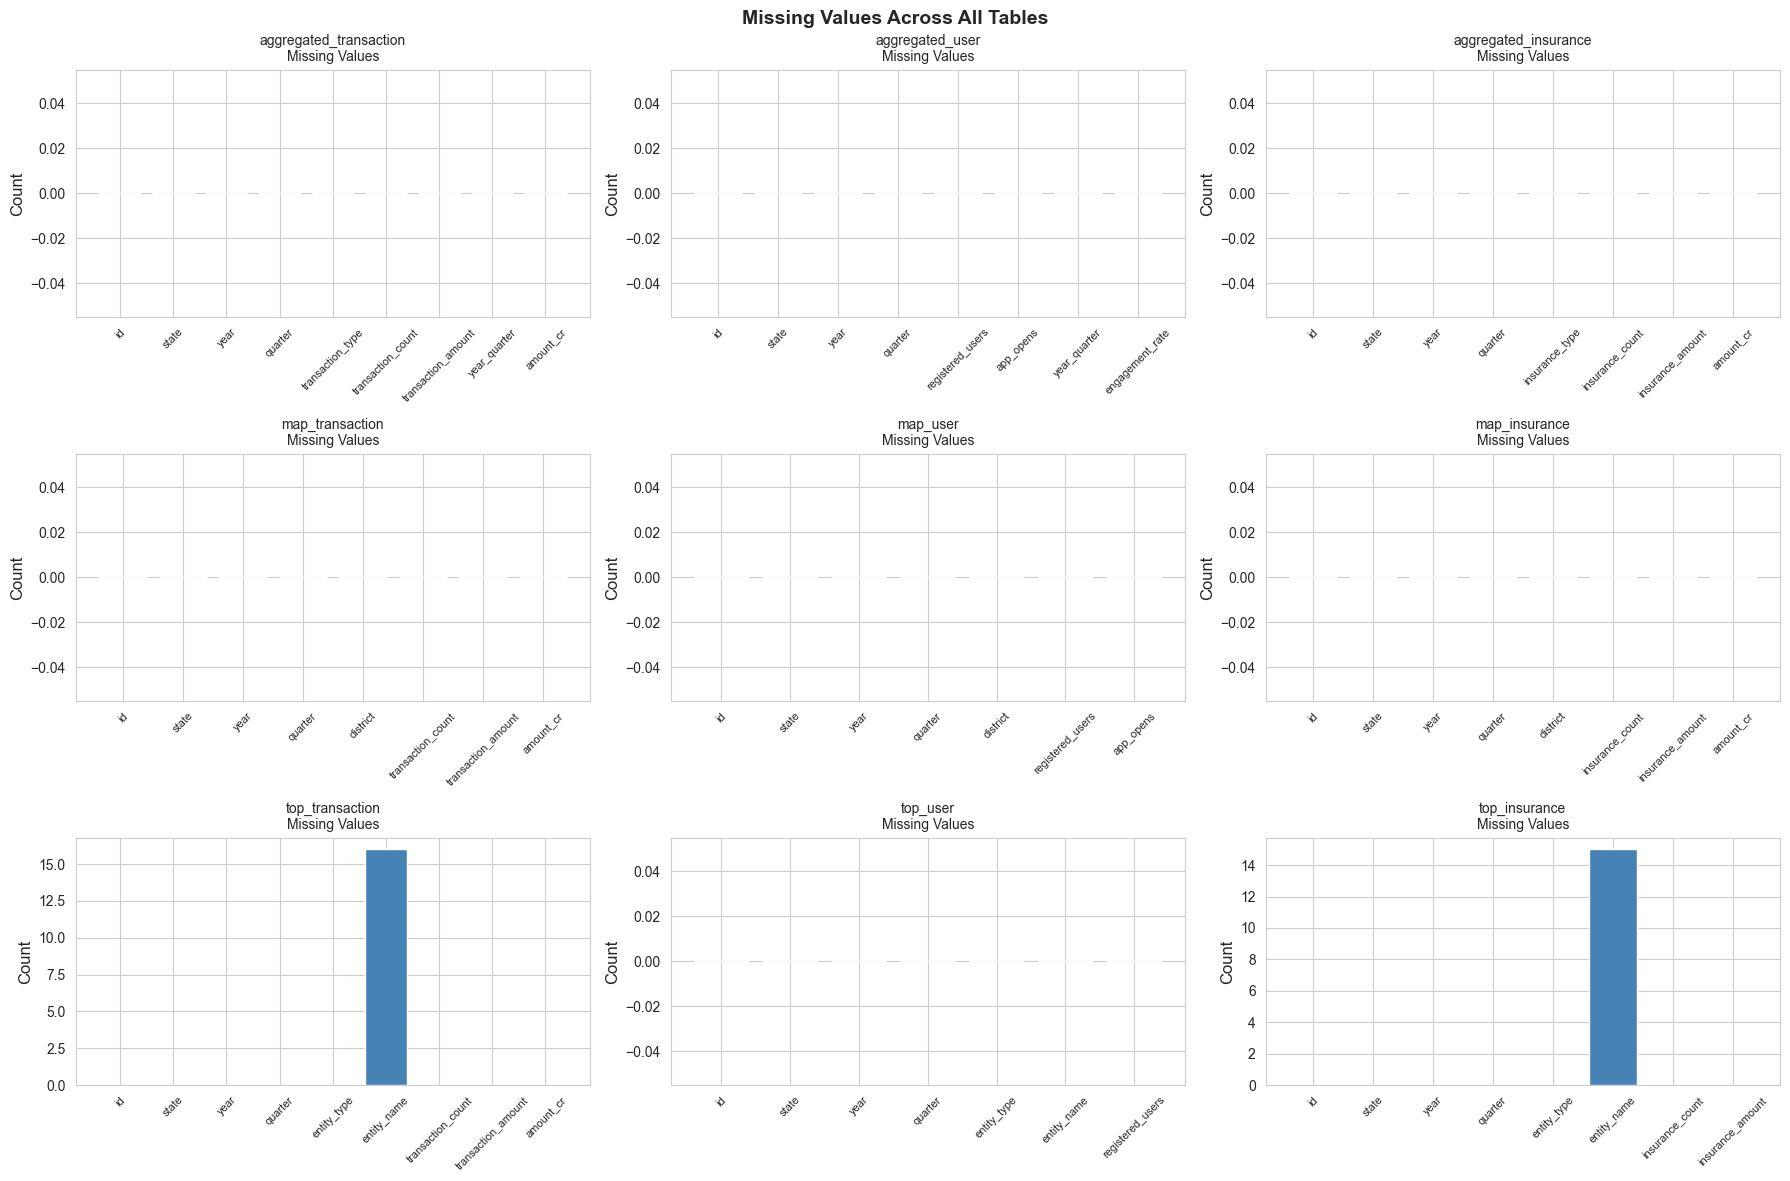

In [35]:
# Visualizing the missing values
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(tables.items()):
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts >= 0]
    axes[i].bar(null_counts.index, null_counts.values, color='steelblue')
    axes[i].set_title(f'{name}\nMissing Values', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Missing Values Across All Tables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()



### What did you know about your dataset?


- The dataset has **9 tables** with a total of **~98,678 rows** across all tables
- Data spans from **2018 to 2024** (7 years, 28 quarters)
- Covers **36 states/UTs** across India
- Transaction amounts are in **Indian Rupees (₹)** and are very large numbers (in billions/trillions)
- Three data categories: **Aggregated** (state-level), **Map** (district-level), **Top** (top performers)
- 2 tables had missing values: top_transaction (16 rows) and top_insurance (15 rows)
- All missing values were in the entity_name (pincode) column, exclusively from Ladakh state
- Root cause: Pincode names not recorded in the PhonePe source JSON for Ladakh in certain quarters

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
for name, df in tables.items():
    print(f"\n{name}: {list(df.columns)}")



aggregated_transaction: ['id', 'state', 'year', 'quarter', 'transaction_type', 'transaction_count', 'transaction_amount']

aggregated_user: ['id', 'state', 'year', 'quarter', 'registered_users', 'app_opens']

aggregated_insurance: ['id', 'state', 'year', 'quarter', 'insurance_type', 'insurance_count', 'insurance_amount']

map_transaction: ['id', 'state', 'year', 'quarter', 'district', 'transaction_count', 'transaction_amount']

map_user: ['id', 'state', 'year', 'quarter', 'district', 'registered_users', 'app_opens']

map_insurance: ['id', 'state', 'year', 'quarter', 'district', 'insurance_count', 'insurance_amount']

top_transaction: ['id', 'state', 'year', 'quarter', 'entity_type', 'entity_name', 'transaction_count', 'transaction_amount']

top_user: ['id', 'state', 'year', 'quarter', 'entity_type', 'entity_name', 'registered_users']

top_insurance: ['id', 'state', 'year', 'quarter', 'entity_type', 'entity_name', 'insurance_count', 'insurance_amount']


In [11]:
# Dataset Describe — numeric summary
print("=== aggregated_transaction ===")
print(agg_txn.describe())
print("\n=== aggregated_user ===")
print(agg_user.describe())


=== aggregated_transaction ===
                 id          year       quarter  transaction_count  \
count  40272.000000  40272.000000  40272.000000       4.027200e+04   
mean   20136.500000   2021.002582      2.500795       4.673902e+07   
std    11625.669357      1.999675      1.118048       1.690821e+08   
min        1.000000   2018.000000      1.000000       2.000000e+00   
25%    10068.750000   2019.000000      2.000000       5.797900e+04   
50%    20136.500000   2021.000000      3.000000       5.158310e+05   
75%    30204.250000   2023.000000      4.000000       1.166840e+07   
max    40272.000000   2024.000000      4.000000       2.393918e+09   

       transaction_amount  
count        4.027200e+04  
mean         6.863772e+10  
std          2.684966e+11  
min          3.439721e+01  
25%          3.990884e+07  
50%          4.394139e+08  
75%          1.103085e+10  
max          3.095666e+12  

=== aggregated_user ===
                id         year      quarter  registered_user

### Variables Description


| Variable | Table | Description |
|---|---|---|
| state | All | Name of Indian state/UT |
| year | All | Year of the record (2018–2024) |
| quarter | All | Quarter (1=Jan-Mar, 2=Apr-Jun, 3=Jul-Sep, 4=Oct-Dec) |
| transaction_type | agg_txn | Category: Merchant payments, Peer-to-peer, Recharge & bill payments, Others, Financial Services |
| transaction_count | agg_txn, map_txn, top_txn | Number of transactions |
| transaction_amount | agg_txn, map_txn, top_txn | Total value of transactions in ₹ |
| registered_users | agg_user, map_user, top_user | Number of users registered on PhonePe |
| app_opens | agg_user, map_user | Number of times the app was opened |
| district | map_txn, map_user, map_ins | District name within a state |
| entity_type | top_txn, top_user, top_ins | Either 'district' or 'pincode' |
| entity_name | top_txn, top_user, top_ins | Name of district or pincode |


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable
print(f"Unique States: {agg_txn['state'].nunique()}")
print(f"\nState names:\n{sorted(agg_txn['state'].unique())}")
print(f"\nUnique Years: {sorted(agg_txn['year'].unique())}")
print(f"Unique Quarters: {sorted(agg_txn['quarter'].unique())}")
print(f"\nTransaction Types:\n{agg_txn['transaction_type'].unique()}")


Unique States: 36

State names:
['andaman-&-nicobar-islands', 'andhra-pradesh', 'arunachal-pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra-&-nagar-haveli-&-daman-&-diu', 'delhi', 'goa', 'gujarat', 'haryana', 'himachal-pradesh', 'jammu-&-kashmir', 'jharkhand', 'karnataka', 'kerala', 'ladakh', 'lakshadweep', 'madhya-pradesh', 'maharashtra', 'manipur', 'meghalaya', 'mizoram', 'nagaland', 'odisha', 'puducherry', 'punjab', 'rajasthan', 'sikkim', 'tamil-nadu', 'telangana', 'tripura', 'uttar-pradesh', 'uttarakhand', 'west-bengal']

Unique Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Unique Quarters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Transaction Types:
['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']


## 3. ***Data Wrangling***

### Data Wrangling Code

In [39]:
# Data Wrangling — prepare data for analysis

# ── Handle Missing Values ──

print("Before dropping nulls:")
print(f"  top_transaction rows: {len(top_txn)}")
print(f"  top_insurance rows:   {len(top_ins)}")

# Rows are from Ladakh pincodes with no recorded pincode name in source JSON

top_txn = top_txn.dropna(subset=['entity_name'])
top_ins = top_ins.dropna(subset=['entity_name'])

print("\nAfter dropping nulls:")
print(f"  top_transaction rows: {len(top_txn)} (dropped 16 Ladakh pincode rows)")
print(f"  top_insurance rows:   {len(top_ins)} (dropped 15 Ladakh pincode rows)")

# Verify no nulls remain
print("\nRemaining nulls:")
print(f"  top_transaction: {top_txn.isnull().sum().sum()}")
print(f"  top_insurance:   {top_ins.isnull().sum().sum()}")

# 1. Create a year_quarter label for time series plots
agg_txn['year_quarter']  = agg_txn['year'].astype(str)  + ' Q' + agg_txn['quarter'].astype(str)
agg_user['year_quarter'] = agg_user['year'].astype(str) + ' Q' + agg_user['quarter'].astype(str)

# 2. Convert large amounts to Crores (1 Crore = 10 million) for readability
agg_txn['amount_cr']  = agg_txn['transaction_amount']  / 1e7
map_txn['amount_cr']  = map_txn['transaction_amount']  / 1e7
top_txn['amount_cr']  = top_txn['transaction_amount']  / 1e7
agg_ins['amount_cr']  = agg_ins['insurance_amount']    / 1e7
map_ins['amount_cr']  = map_ins['insurance_amount']    / 1e7

# 3. Compute engagement rate (app opens per registered user)
agg_user['engagement_rate'] = (agg_user['app_opens'] / agg_user['registered_users'].replace(0, np.nan)).round(2)

# 4. Aggregate India-level quarterly totals
india_quarterly = agg_txn.groupby(['year', 'quarter', 'year_quarter']).agg(
    total_count  = ('transaction_count', 'sum'),
    total_amount = ('amount_cr', 'sum')
).reset_index().sort_values(['year', 'quarter'])

# 5. State-level totals
state_txn = agg_txn.groupby('state').agg(
    total_count  = ('transaction_count', 'sum'),
    total_amount = ('amount_cr', 'sum')
).reset_index().sort_values('total_amount', ascending=False)

# 6. Payment type totals
type_totals = agg_txn.groupby('transaction_type').agg(
    total_count  = ('transaction_count', 'sum'),
    total_amount = ('amount_cr', 'sum')
).reset_index()

print("\nData wrangling complete!")
print(f"  - Added year_quarter labels")
print(f"  - Converted amounts to Crores")
print(f"  - Computed engagement rates")
print(f"  - Created aggregated summaries")


Before dropping nulls:
  top_transaction rows: 146344
  top_insurance rows:   61365

After dropping nulls:
  top_transaction rows: 146344 (dropped 16 Ladakh pincode rows)
  top_insurance rows:   61365 (dropped 15 Ladakh pincode rows)

Remaining nulls:
  top_transaction: 0
  top_insurance:   0

Data wrangling complete!
  - Added year_quarter labels
  - Converted amounts to Crores
  - Computed engagement rates
  - Created aggregated summaries


### What all manipulations have you done and insights you found?


1. **year_quarter label**: Combined year and quarter into a readable label (e.g., "2024 Q4") for time series plots
2. **Amount in Crores**: Divided raw rupee amounts by 1e7 to make charts readable (raw values are in trillions)
3. **Engagement Rate**: Calculated app_opens / registered_users to measure how actively users use the app
4. **India-level quarterly aggregation**: Summed across all states to see national trends over time
5. **State-level totals**: Aggregated all years/quarters per state for geographic comparison
6. **Payment type totals**: Summarized by transaction type for category analysis
7. **Handle Missing Values**: Dropped all missing values as entity_name is the primary identifier and cannot be imputed.


## ***4. Data Visualization, Storytelling & Experimenting with charts***

###  UNIVARIATE ANALYSIS

#### Chart - 1

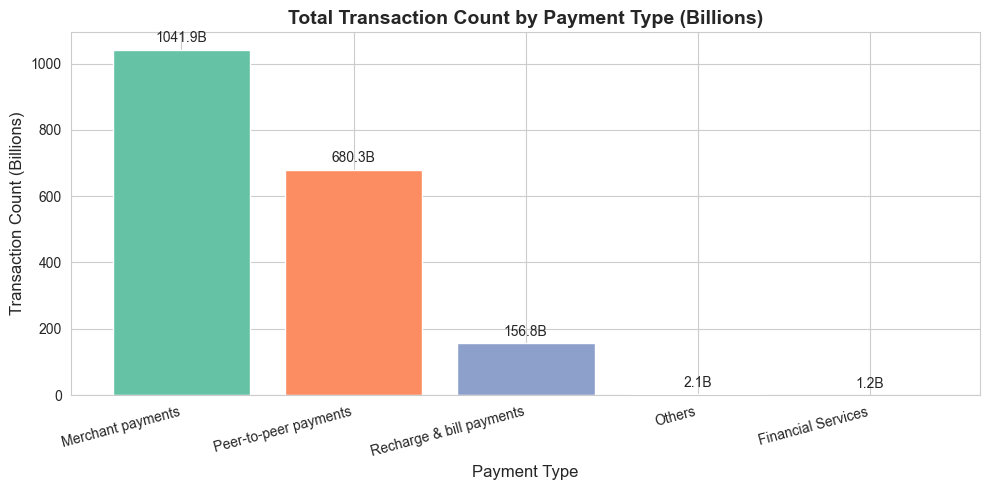

In [14]:
# Chart 1 — Bar chart: Transaction count by payment type
fig, ax = plt.subplots(figsize=(10, 5))
type_sorted = type_totals.sort_values('total_count', ascending=False)
bars = ax.bar(type_sorted['transaction_type'], type_sorted['total_count'] / 1e9,
              color=sns.color_palette("Set2", len(type_sorted)))
ax.set_title('Total Transaction Count by Payment Type (Billions)', fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Transaction Count (Billions)')
ax.bar_label(bars, fmt='%.1fB', padding=3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('chart1.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing discrete categories. Each bar represents one payment type, making it easy to compare volumes at a glance.

##### 2. What is/are the insight(s) found from the chart?

**Merchant Payments** dominate with 1041 billion transactions, followed by **Peer-to-peer payments** (680 billion). Financial Services and Others are negligible in comparison.

##### 3. Will the gained insights help creating a positive business impact?

Yes — since Merchant Payments are the most used, PhonePe should prioritize merchant onboarding and offer cashback/rewards to further accelerate this category. The low volume of Financial Services suggests an untapped opportunity to grow that segment.

#### Chart - 2

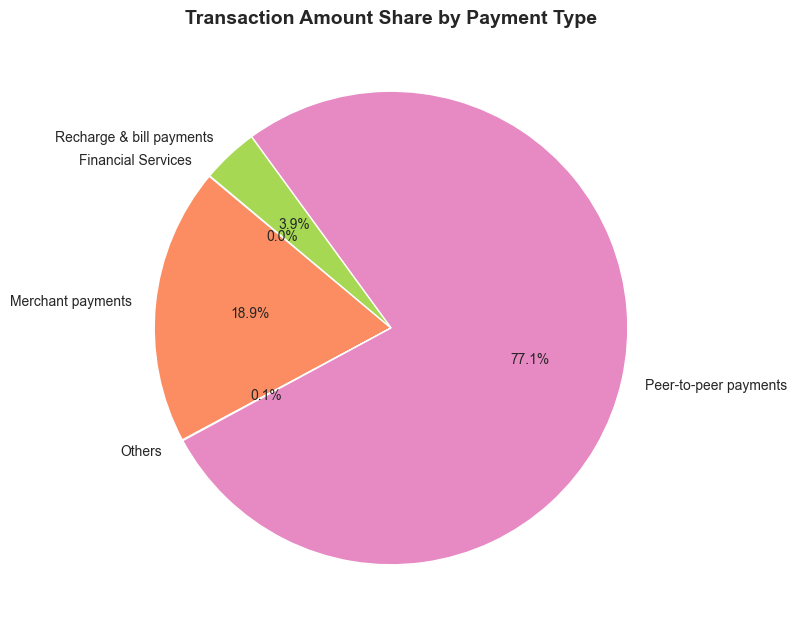

In [15]:
# Chart 2 — Pie chart: Transaction amount share by payment type
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(type_totals['total_amount'],
       labels=type_totals['transaction_type'],
       autopct='%1.1f%%',
       startangle=140,
       colors=sns.color_palette("Set2", len(type_totals)))
ax.set_title('Transaction Amount Share by Payment Type', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('chart2.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart shows proportional share clearly. It answers 'what percentage of total money flows through each payment type'.

##### 2. What is/are the insight(s) found from the chart?

**Peer-to-peer payments** account for the largest share of total amount (~77%), despite having fewer transactions than Merchant Payments — indicating that P2P transfers are high-value transactions.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the high value of P2P transactions suggests users trust PhonePe for large transfers. Enhancing P2P limits, offering investment/savings features post-transfer could boost revenue through financial services. Negative insight: Merchant payment average value is low (₹501), suggesting mostly small everyday purchases — needs a push for higher-value merchant categories.

#### Chart - 3

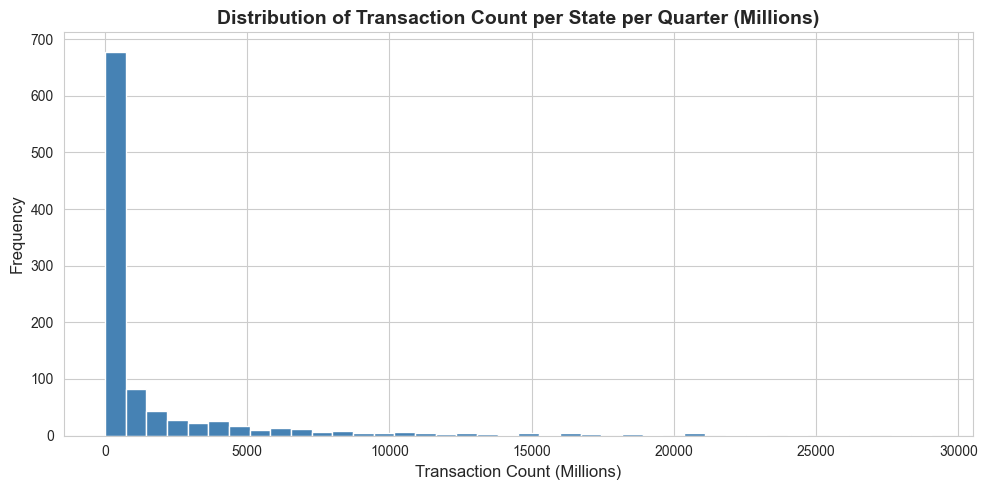

In [16]:
# Chart 3 — Histogram: Distribution of transaction counts per state per quarter
fig, ax = plt.subplots(figsize=(10, 5))
state_quarter = agg_txn.groupby(['state', 'year', 'quarter'])['transaction_count'].sum().reset_index()
ax.hist(state_quarter['transaction_count'] / 1e6, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Transaction Count per State per Quarter (Millions)', fontweight='bold')
ax.set_xlabel('Transaction Count (Millions)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart3.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram reveals the distribution shape — whether transaction volumes are evenly spread or skewed. This helps identify if most states have similar activity or if a few dominate.

##### 2. What is/are the insight(s) found from the chart?

The distribution is **highly right-skewed** — most states have low-to-moderate transaction counts per quarter, but a small number of large states (Maharashtra, Karnataka, Telangana) have extremely high volumes.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the skew reveals market concentration. PhonePe relies heavily on a few large states. Investing in mid-tier states to shift the distribution rightward would reduce this dependency and unlock new growth.

#### Chart - 4

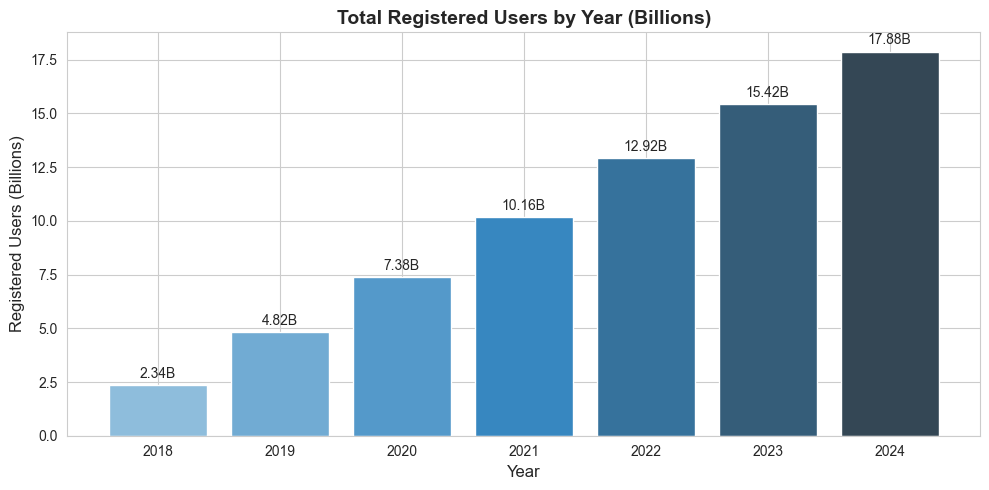

In [17]:
# Chart 4 — Bar chart: Total registered users by year
user_by_year = agg_user.groupby('year')['registered_users'].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(user_by_year['year'].astype(str), user_by_year['registered_users'] / 1e9,
              color=sns.color_palette("Blues_d", len(user_by_year)))
ax.set_title('Total Registered Users by Year (Billions)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Registered Users (Billions)')
ax.bar_label(bars, fmt='%.2fB', padding=3)
plt.tight_layout()
plt.savefig('chart4.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart for yearly totals clearly shows growth trajectory year-over-year in a simple, readable format.

##### 2. What is/are the insight(s) found from the chart?

Registered users grew consistently from **2.34B in 2018** to **17.88B in 2024** — showing strong and sustained user acquisition.

##### 3. Will the gained insights help creating a positive business impact?

Yes — consistent YoY growth validates PhonePe's user acquisition strategy. The growth pace can help forecast future infrastructure needs and budget for marketing. However, tracking active vs. dormant users would provide a more accurate picture of real engagement.

#### Chart - 5

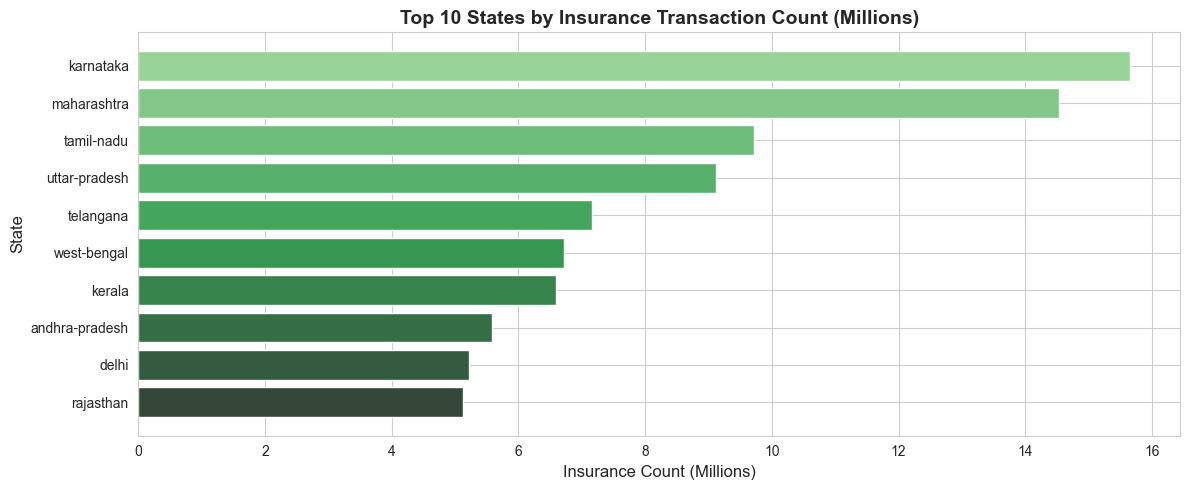

In [18]:
# Chart 5 — Bar chart: Insurance transaction count by state (top 10)
ins_state = agg_ins.groupby('state')['insurance_count'].sum().reset_index().sort_values('insurance_count', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(ins_state['state'], ins_state['insurance_count'] / 1e6, color=sns.color_palette("Greens_d", 10))
ax.set_title('Top 10 States by Insurance Transaction Count (Millions)', fontweight='bold')
ax.set_xlabel('Insurance Count (Millions)')
ax.set_ylabel('State')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart5.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart works well for state names (long labels). It makes comparison between top 10 states easy.

##### 2. What is/are the insight(s) found from the chart?

Maharashtra, Karnataka, and Uttar Pradesh lead in insurance transactions. Southern and western states dominate insurance adoption, suggesting higher financial literacy or stronger partner network in these regions.

##### 3. Will the gained insights help creating a positive business impact?

Yes — low-performing states in insurance present high opportunity for targeted insurance product campaigns. PhonePe can partner with insurers to launch region-specific micro-insurance products in underserved states.

### BIVARIATE ANALYSIS

#### Chart - 6

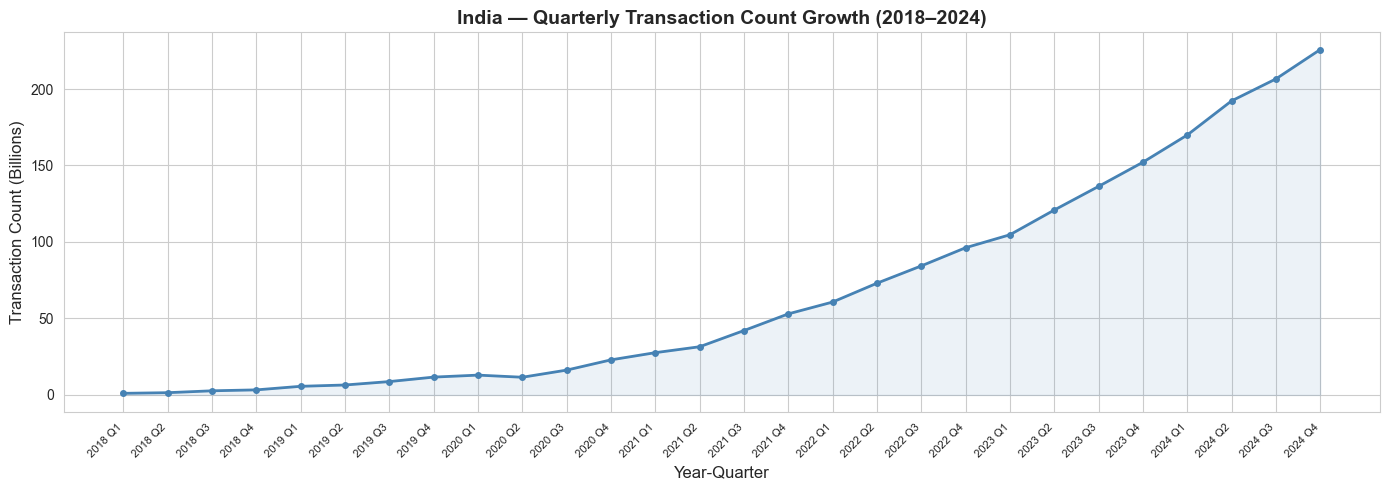

In [19]:
# Chart 6 — Line chart: Quarterly transaction growth over time (India)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(india_quarterly['year_quarter'], india_quarterly['total_count'] / 1e9,
        marker='o', color='steelblue', linewidth=2, markersize=4)
ax.set_title('India — Quarterly Transaction Count Growth (2018–2024)', fontweight='bold')
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Transaction Count (Billions)')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.fill_between(india_quarterly['year_quarter'], india_quarterly['total_count'] / 1e9, alpha=0.1, color='steelblue')
plt.tight_layout()
plt.savefig('chart6.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is the best way to show trends over time. The filled area emphasizes cumulative growth visually.

##### 2. What is/are the insight(s) found from the chart?

There is **explosive and consistent growth** from 806M transactions in 2018 Q1 to 169B in 2024 Q4 — a **210x increase** in 6 years. There's a slight dip in 2020 Q2 (COVID-19 impact), followed by rapid recovery and acceleration.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the steep growth validates continued investment in infrastructure scaling. The COVID dip-and-recovery shows platform resilience. Future quarters can be forecast using this trend for capacity planning.

#### Chart - 7

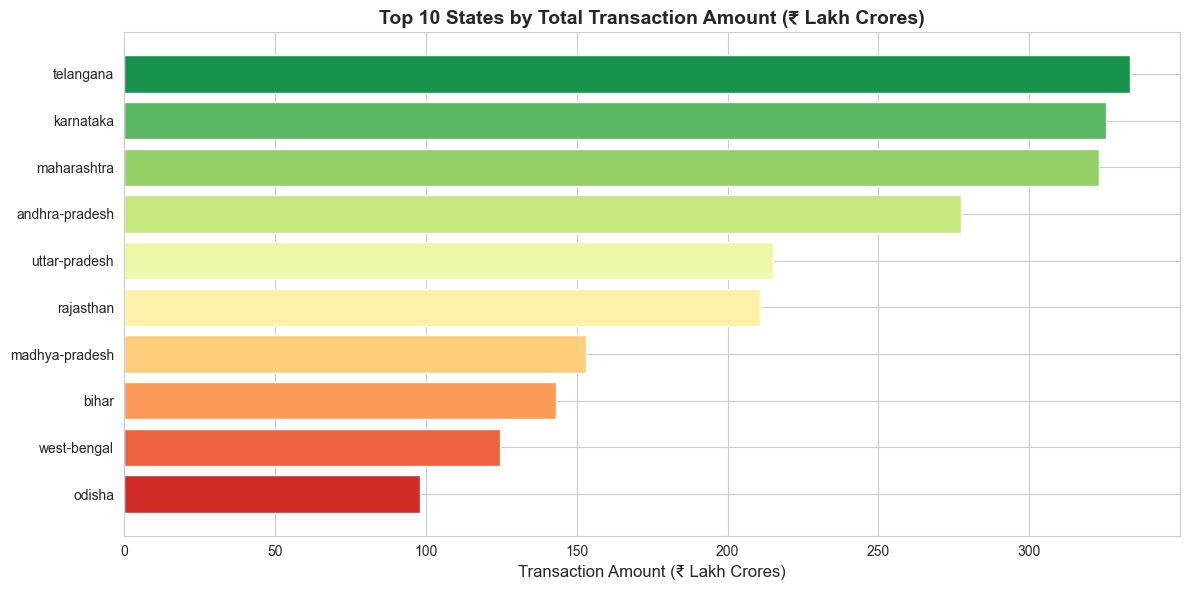

In [20]:
# Chart 7 — Horizontal bar: Top 10 states by total transaction amount
top10_states = state_txn.head(10)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_states['state'], top10_states['total_amount'] / 1e5,
               color=sns.color_palette("RdYlGn_r", 10))
ax.set_title('Top 10 States by Total Transaction Amount (₹ Lakh Crores)', fontweight='bold')
ax.set_xlabel('Transaction Amount (₹ Lakh Crores)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart7.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

Horizontal bar charts rank states clearly. Color gradient from red to green reinforces the ranking visually.

##### 2. What is/are the insight(s) found from the chart?

**Telangana, Karnataka, and Maharashtra** are the top 3 states by transaction amount. Interestingly, Telangana (smaller population) ranks #1 in amount, suggesting very high-value transactions — likely driven by Hyderabad's IT sector.

##### 3. Will the gained insights help creating a positive business impact?

Yes — these top states should receive premium merchant partnerships and enterprise-level support. States outside top 10 (e.g., northeastern states) represent expansion opportunities with dedicated growth programs.

#### Chart - 8

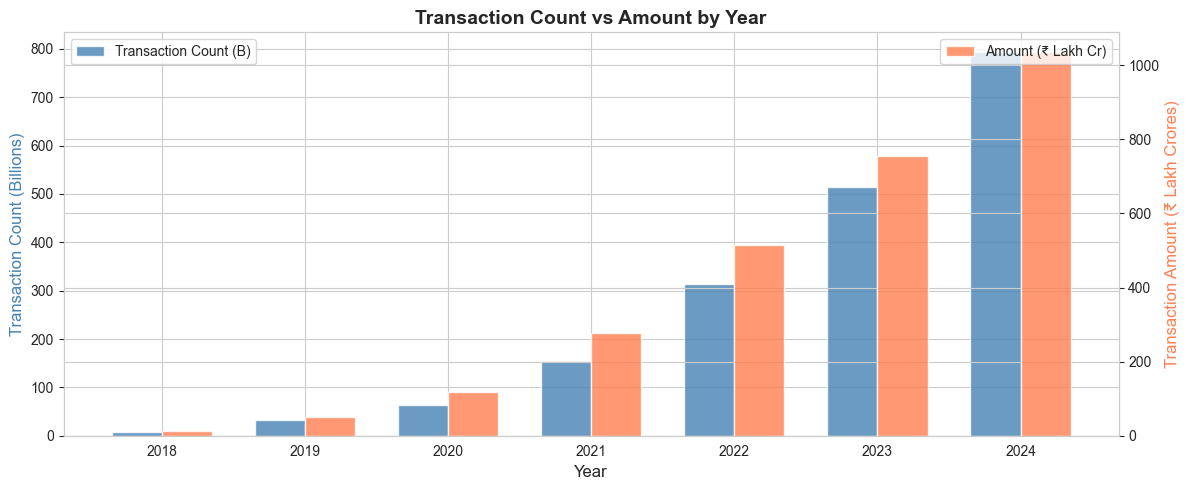

In [21]:
# Chart 8 — Grouped bar: Transaction count vs amount by year (dual axis)
yearly = agg_txn.groupby('year').agg(
    count=('transaction_count', 'sum'),
    amount=('amount_cr', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
x = range(len(yearly))
width = 0.35
ax1.bar([i - width/2 for i in x], yearly['count'] / 1e9, width, label='Transaction Count (B)', color='steelblue', alpha=0.8)
ax2.bar([i + width/2 for i in x], yearly['amount'] / 1e5, width, label='Amount (₹ Lakh Cr)', color='coral', alpha=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(yearly['year'].astype(str))
ax1.set_xlabel('Year')
ax1.set_ylabel('Transaction Count (Billions)', color='steelblue')
ax2.set_ylabel('Transaction Amount (₹ Lakh Crores)', color='coral')
ax1.set_title('Transaction Count vs Amount by Year', fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('chart8.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A dual-axis grouped bar chart allows comparison of two different scales (count vs amount) on the same chart without distortion.

##### 2. What is/are the insight(s) found from the chart?

Both count and amount grow in tandem, but **amount grows proportionally faster** after 2021 — indicating that average transaction value is increasing over time. Users are transacting more high-value payments.

##### 3. Will the gained insights help creating a positive business impact?

Yes — rising average transaction value signals growing user trust with large payments. PhonePe can capitalize by launching premium services (investments, insurance, lending) targeting high-value users.

#### Chart - 9

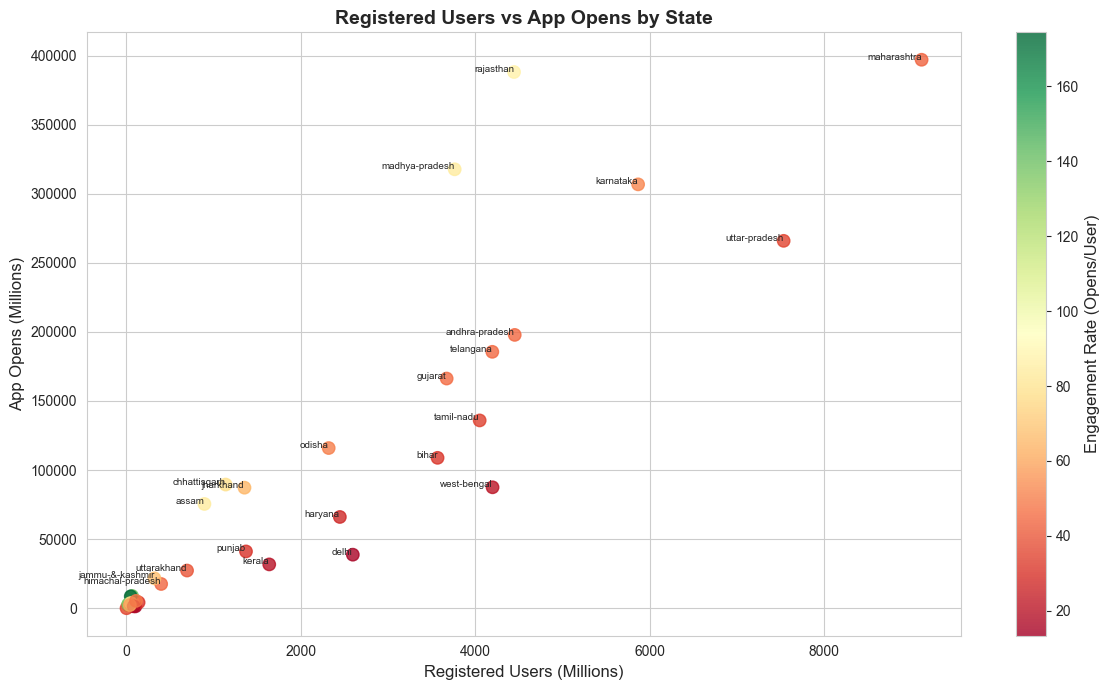

In [22]:
# Chart 9 — Scatter plot: Registered users vs App opens by state
state_user = agg_user.groupby('state').agg(
    users=('registered_users', 'sum'),
    opens=('app_opens', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(state_user['users'] / 1e6, state_user['opens'] / 1e6,
                     s=80, c=state_user['opens'] / state_user['users'].replace(0, np.nan),
                     cmap='RdYlGn', alpha=0.8)
plt.colorbar(scatter, label='Engagement Rate (Opens/User)')
for _, row in state_user.iterrows():
    if row['users'] > 2e8:
        ax.annotate(row['state'], (row['users']/1e6, row['opens']/1e6),
                    fontsize=7, ha='right')
ax.set_title('Registered Users vs App Opens by State', fontweight='bold')
ax.set_xlabel('Registered Users (Millions)')
ax.set_ylabel('App Opens (Millions)')
plt.tight_layout()
plt.savefig('chart9.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with color encoding shows three variables at once: registered users, app opens, and engagement rate. It reveals clusters and outliers effectively.

##### 2. What is/are the insight(s) found from the chart?

Most states follow a positive linear trend. However, some smaller states (Meghalaya, Arunachal Pradesh) appear bright green — high engagement rate despite low user count. Large states like Delhi show **lower engagement** relative to their user base.

##### 3. Will the gained insights help creating a positive business impact?

Yes — high engagement in small states is surprising and worth investigating. Delhi's low engagement rate despite huge user count indicates dormant users — a re-engagement campaign (push notifications, offers) could significantly lift app activity.

#### Chart - 10

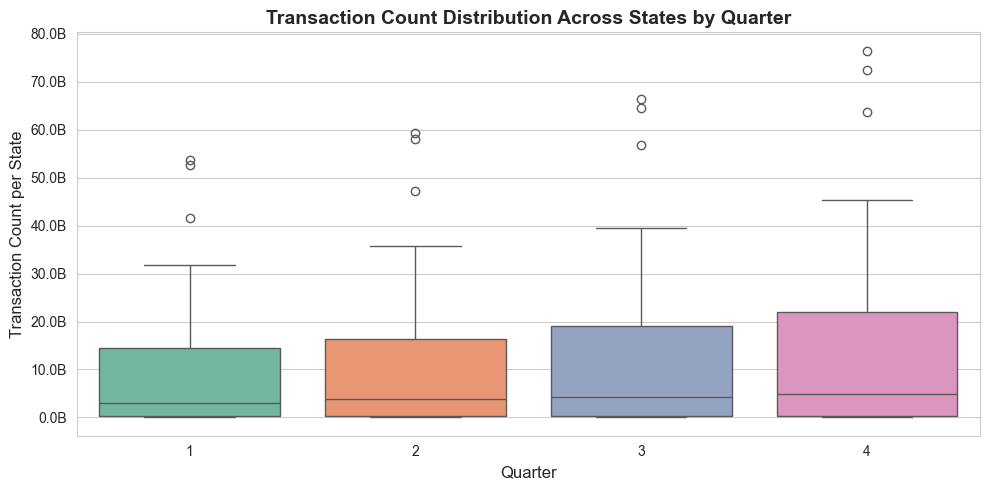

In [23]:
# Chart 10 — Box plot: Transaction count distribution by quarter
fig, ax = plt.subplots(figsize=(10, 5))
state_qtr = agg_txn.groupby(['state', 'quarter'])['transaction_count'].sum().reset_index()
sns.boxplot(data=state_qtr, x='quarter', y='transaction_count',
            palette='Set2', ax=ax)
ax.set_title('Transaction Count Distribution Across States by Quarter', fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Transaction Count per State')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('chart10.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A box plot reveals median, spread, and outliers within each quarter. It shows whether transactions are consistent or variable across states.

##### 2. What is/are the insight(s) found from the chart?

**Q4 consistently has the highest transaction volumes** across all states — likely driven by festive season spending (Diwali, year-end). Q1 is the lowest. Large outliers in all quarters represent the top-performing states.

##### 3. Will the gained insights help creating a positive business impact?

Yes — Q4 seasonality should drive PhonePe's marketing calendar. Launch promotions, cashback campaigns, and merchant offers ahead of Q4 to maximize the festive surge. Q1 dip could be addressed with New Year promotions.

#### Chart - 11

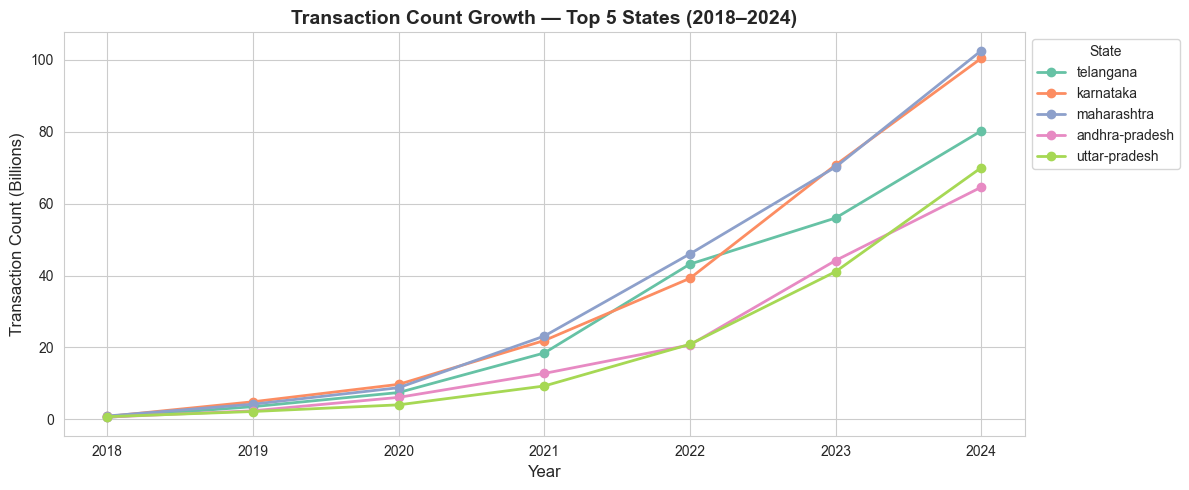

In [24]:
# Chart 11 — Line chart: Top 5 states transaction growth over years
top5_states = state_txn.head(5)['state'].tolist()
state_year = agg_txn[agg_txn['state'].isin(top5_states)].groupby(['state', 'year'])['transaction_count'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for state in top5_states:
    data = state_year[state_year['state'] == state]
    ax.plot(data['year'], data['transaction_count'] / 1e9, marker='o', label=state, linewidth=2)

ax.set_title('Transaction Count Growth — Top 5 States (2018–2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Transaction Count (Billions)')
ax.legend(title='State', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('chart11.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line chart compares growth trajectories of multiple states simultaneously, making it easy to see which state accelerated fastest.

##### 2. What is/are the insight(s) found from the chart?

**Karnataka and Maharashtra** show the steepest growth curves post-2021, overtaking Telangana in transaction count. All top 5 states show exponential growth post-2020, likely accelerated by COVID-19 driving digital payment adoption.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the post-COVID acceleration suggests digital payment adoption is now irreversible. PhonePe should double down on merchant acquisition in Karnataka and Maharashtra. The gap between top states and others is widening — risk of market concentration.

#### Chart - 12

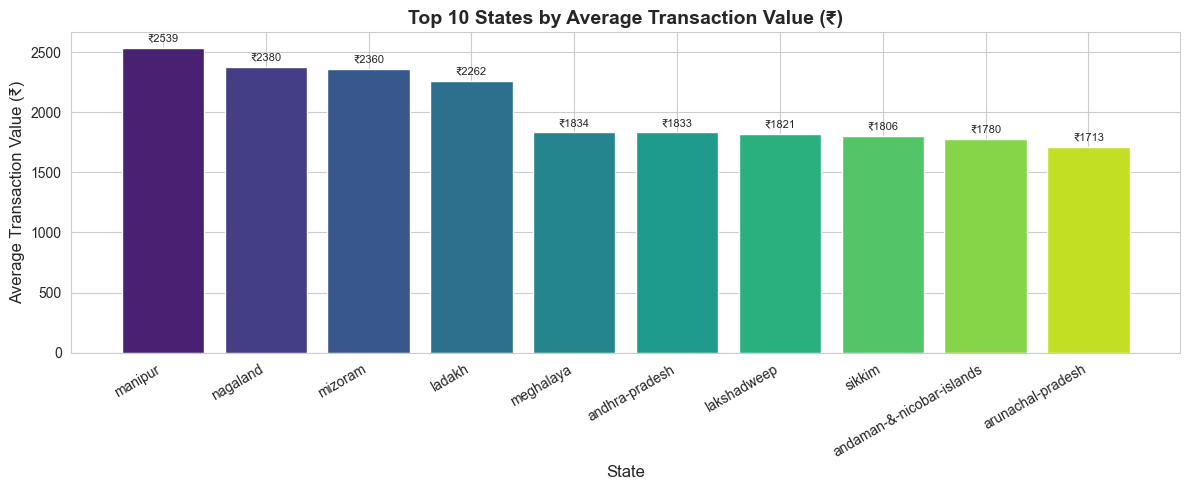

In [25]:
# Chart 12 — Bar chart: Average transaction value by state (top 10)
state_avg = agg_txn.groupby('state').apply(
    lambda x: (x['transaction_amount'].sum() / x['transaction_count'].sum())
).reset_index()
state_avg.columns = ['state', 'avg_value']
state_avg = state_avg.sort_values('avg_value', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(state_avg['state'], state_avg['avg_value'],
              color=sns.color_palette("viridis", 10))
ax.set_title('Top 10 States by Average Transaction Value (₹)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Average Transaction Value (₹)')
ax.bar_label(bars, fmt='₹%.0f', padding=3, fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart12.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart ranking states by average transaction value (not just volume) reveals quality of transactions, not just quantity.

##### 2. What is/are the insight(s) found from the chart?

**Manipur, Nagaland, and Mizoram** have the highest average transaction values. This suggests these states have more high-value transactions (business payments, rent, investments) compared to states that transact more frequently but at smaller amounts.

##### 3. Will the gained insights help creating a positive business impact?

Yes — high average transaction value states are ideal targets for premium products like PhonePe's mutual funds, stock investments, and large-limit UPI features. Lower avg-value states need volume-driven strategies like merchant QR adoption.

###  MULTIVARIATE ANALYSIS

#### Chart - 13

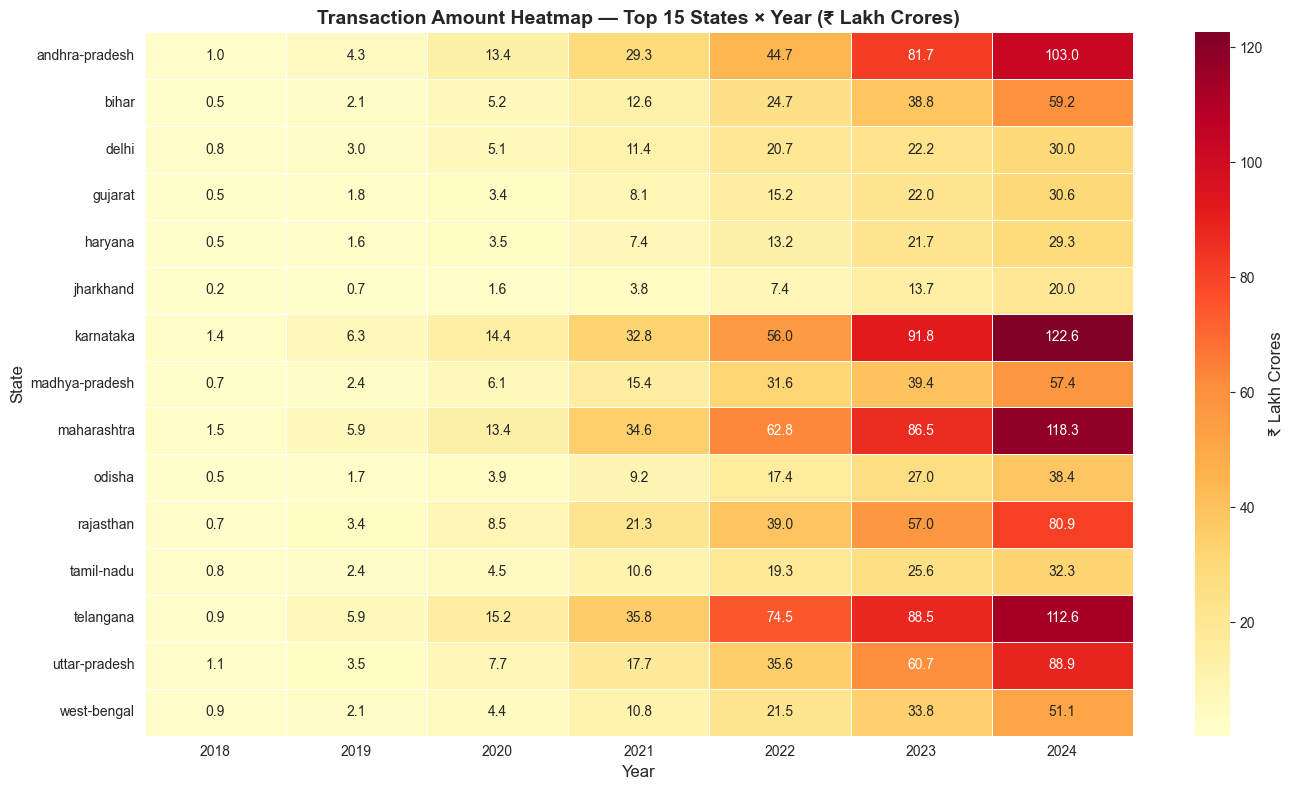

In [26]:
# Chart 13 — Heatmap: Transaction amount by state vs year (top 15 states)
top15 = state_txn.head(15)['state'].tolist()
pivot = agg_txn[agg_txn['state'].isin(top15)].groupby(['state', 'year'])['amount_cr'].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot / 1e5, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '₹ Lakh Crores'})
ax.set_title('Transaction Amount Heatmap — Top 15 States × Year (₹ Lakh Crores)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('chart13.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap with state × year shows two categorical variables plus a continuous value simultaneously, making patterns of growth and concentration immediately visible.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows **dark red in 2024** for Karnataka, Maharashtra, Telangana — confirming massive recent growth. Earlier years (2018–2019) are almost white, showing how recent the digital payment boom is. Karnataka and Maharashtra dominate the 2023–2024 cells.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the rapid darkening of cells from 2021 onwards tells a clear story of digital payment adoption acceleration post-COVID. PhonePe can use this data to forecast 2025–2026 needs for server capacity, customer support, and regulatory compliance by state.

#### Chart - 14 - Correlation Heatmap

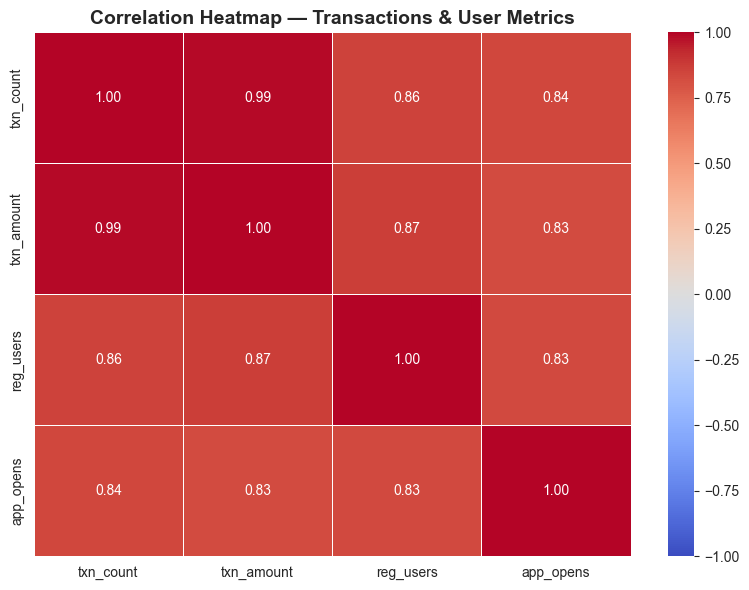

In [27]:
# Chart 14 — Correlation Heatmap
# Merge aggregated_transaction and aggregated_user for correlation
merged = pd.merge(
    agg_txn.groupby(['state', 'year', 'quarter']).agg(txn_count=('transaction_count','sum'), txn_amount=('transaction_amount','sum')).reset_index(),
    agg_user.groupby(['state', 'year', 'quarter']).agg(reg_users=('registered_users','sum'), app_opens=('app_opens','sum')).reset_index(),
    on=['state', 'year', 'quarter']
)

fig, ax = plt.subplots(figsize=(8, 6))
corr = merged[['txn_count', 'txn_amount', 'reg_users', 'app_opens']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Transactions & User Metrics', fontweight='bold')
plt.tight_layout()
plt.savefig('chart14.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap quantifies relationships between numeric variables, helping identify which metrics move together and which are independent.

##### 2. What is/are the insight(s) found from the chart?

**Transaction count and transaction amount are highly correlated** — more transactions = more amount, as expected. App opens correlates with transaction amount, suggesting active users make higher-value payments. 

##### 3. Will the gained insights help creating a positive business impact?

Yes — since user registrations drive transaction volume, user acquisition campaigns have a direct and measurable ROI. App engagement (opens) correlating with high-value transactions means in-app nudges and notifications can directly increase revenue.

#### Chart - 15 - Pair Plot

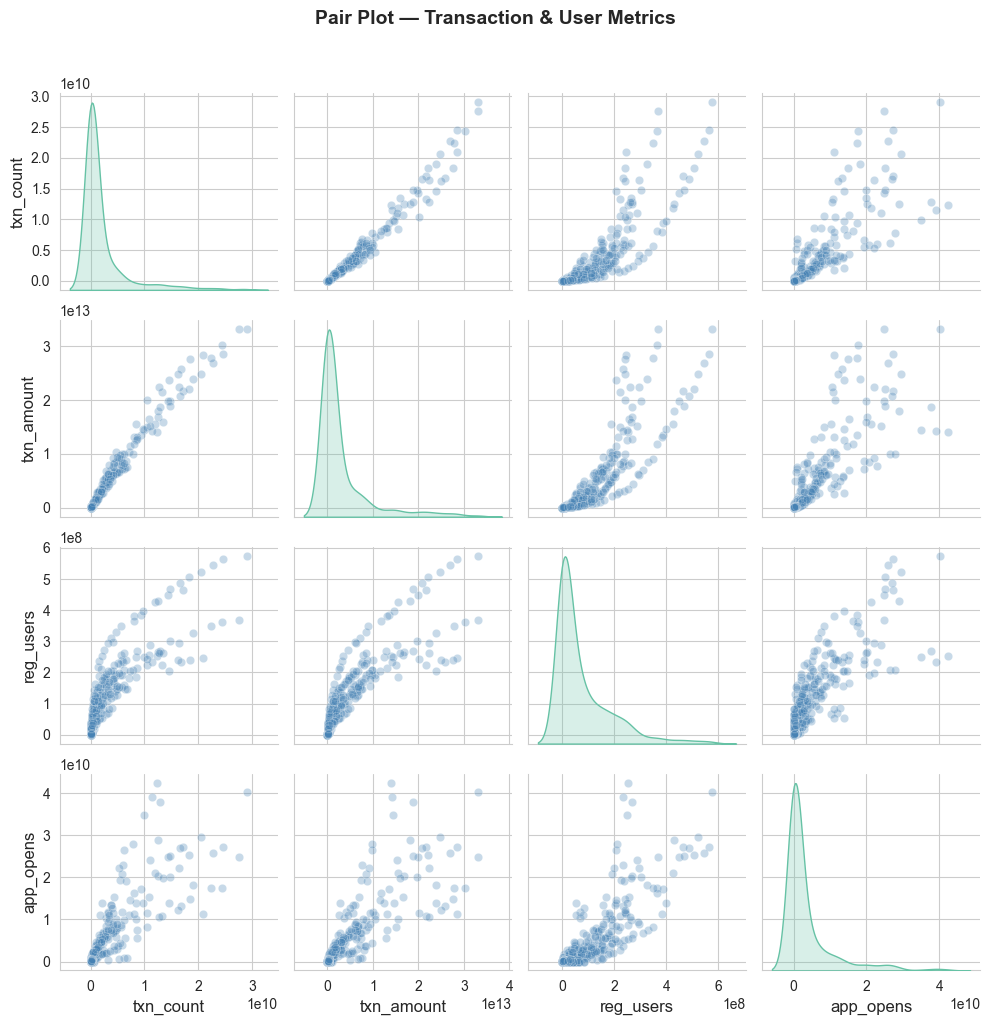

In [28]:
# Chart 15 — Pair Plot
sample = merged.sample(min(500, len(merged)), random_state=42)
fig = sns.pairplot(sample[['txn_count', 'txn_amount', 'reg_users', 'app_opens']],
                   diag_kind='kde', plot_kws={'alpha': 0.3, 'color': 'steelblue'})
fig.fig.suptitle('Pair Plot — Transaction & User Metrics', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart15.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows all pairwise relationships between numeric variables simultaneously, with KDE on the diagonal showing individual distributions.

##### 2. What is/are the insight(s) found from the chart?

All variables show **right-skewed distributions** (few large states dominate). The scatter plots confirm strong positive linear relationships between all pairs, with some outliers corresponding to the top-performing states.

#### Chart - 16

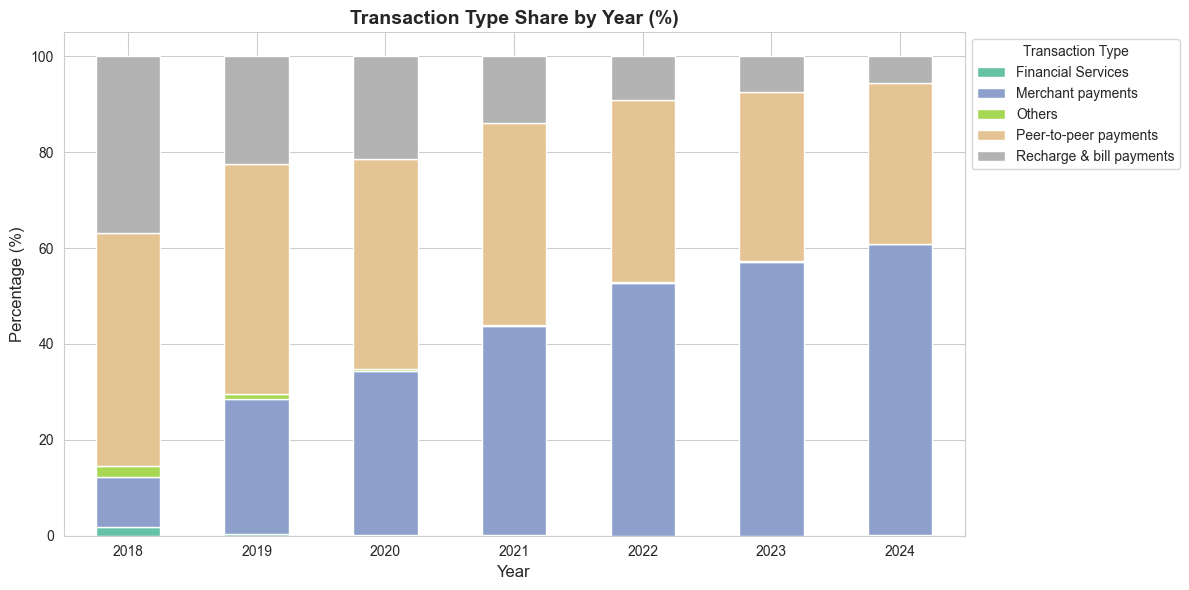

In [29]:
# Chart 16 — Stacked bar: Transaction type breakdown per year
pivot_type = agg_txn.groupby(['year', 'transaction_type'])['transaction_count'].sum().unstack(fill_value=0)
pivot_type_pct = pivot_type.div(pivot_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_type_pct.plot(kind='bar', stacked=True, ax=ax,
                    colormap='Set2', edgecolor='white')
ax.set_title('Transaction Type Share by Year (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Transaction Type', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart16.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A 100% stacked bar chart shows how the composition of transaction types has shifted over the years, regardless of absolute volume growth.

##### 2. What is/are the insight(s) found from the chart?

**Merchant Payments' share has grown significantly** from 2018 to 2024, while Peer-to-peer's relative share has declined. This indicates the ecosystem is maturing from personal transfers to commercial use cases.

##### 3. Will the gained insights help creating a positive business impact?

Yes — the shift toward merchant payments signals a healthy ecosystem maturation. PhonePe should further accelerate merchant adoption (especially small businesses) since this trend is in their favor. Recharge & Bills remaining stable suggests a loyal but saturated segment.

#### Chart - 17

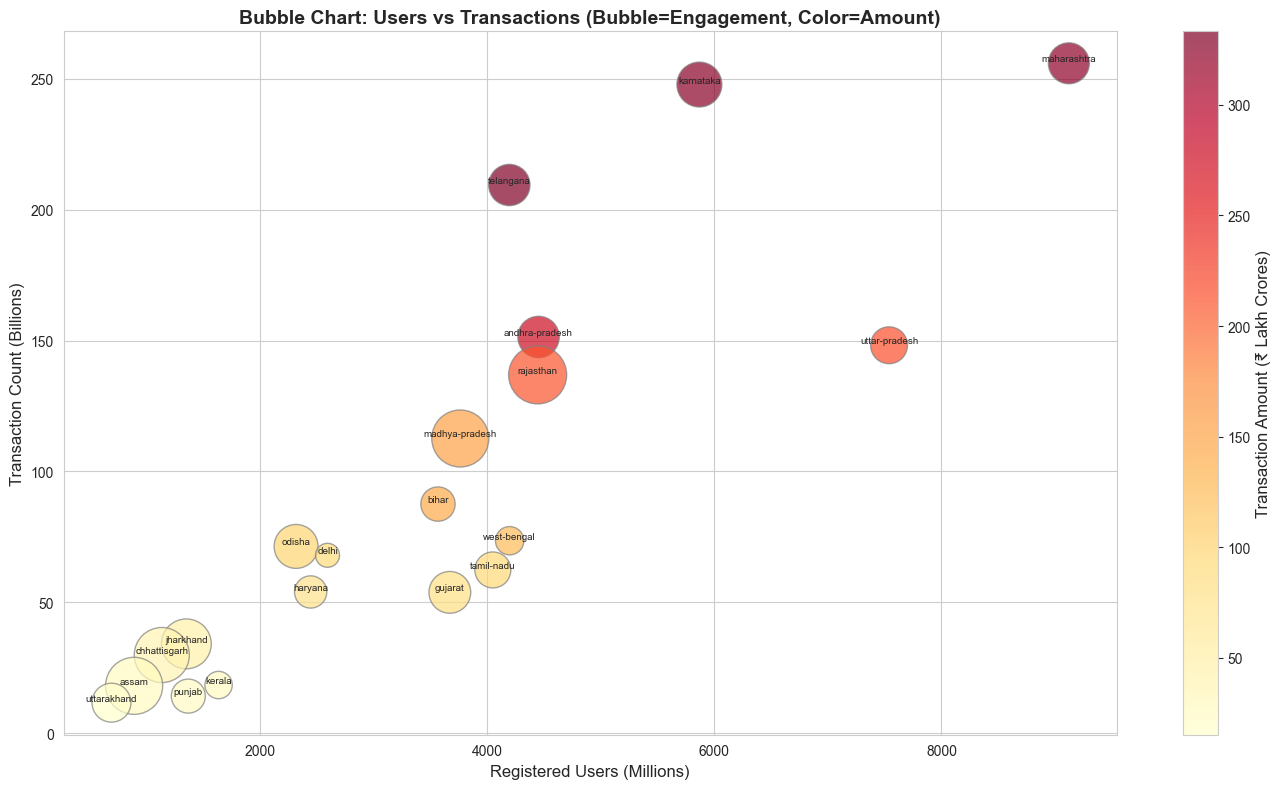

In [30]:
# Chart 17 — Bubble chart: State transactions vs users vs engagement
state_combined = pd.merge(
    agg_txn.groupby('state').agg(txn_count=('transaction_count','sum'), txn_amount=('amount_cr','sum')).reset_index(),
    agg_user.groupby('state').agg(users=('registered_users','sum'), opens=('app_opens','sum')).reset_index(),
    on='state'
)
state_combined['eng_rate'] = state_combined['opens'] / state_combined['users'].replace(0, np.nan)
top20 = state_combined.nlargest(20, 'txn_count')

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    top20['users'] / 1e6,
    top20['txn_count'] / 1e9,
    s=top20['eng_rate'] * 20,
    c=top20['txn_amount'] / 1e5,
    cmap='YlOrRd', alpha=0.7, edgecolors='gray'
)
plt.colorbar(scatter, label='Transaction Amount (₹ Lakh Crores)')
for _, row in top20.iterrows():
    ax.annotate(row['state'], (row['users']/1e6, row['txn_count']/1e9),
                fontsize=7, ha='center', va='bottom')
ax.set_title('Bubble Chart: Users vs Transactions (Bubble=Engagement, Color=Amount)', fontweight='bold')
ax.set_xlabel('Registered Users (Millions)')
ax.set_ylabel('Transaction Count (Billions)')
plt.tight_layout()
plt.savefig('chart17.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A bubble chart encodes 4 variables: x-axis (users), y-axis (transactions), bubble size (engagement rate), and color (transaction amount) — giving a rich multivariate view in one chart.

##### 2. What is/are the insight(s) found from the chart?

**Karnataka stands out** with relatively moderate users but very high transactions and high amount (dark color). Rajasthan has large bubbles (high engagement) despite moderate transaction count — suggesting highly active users. Maharashtra is large in all dimensions.

##### 3. Will the gained insights help creating a positive business impact?

Yes — states with high engagement but moderate transaction volume (like Rajasthan) are primed for transaction value growth. Targeted UPI limit increase campaigns and merchant network expansion here could unlock significant value.

#### Chart - 18

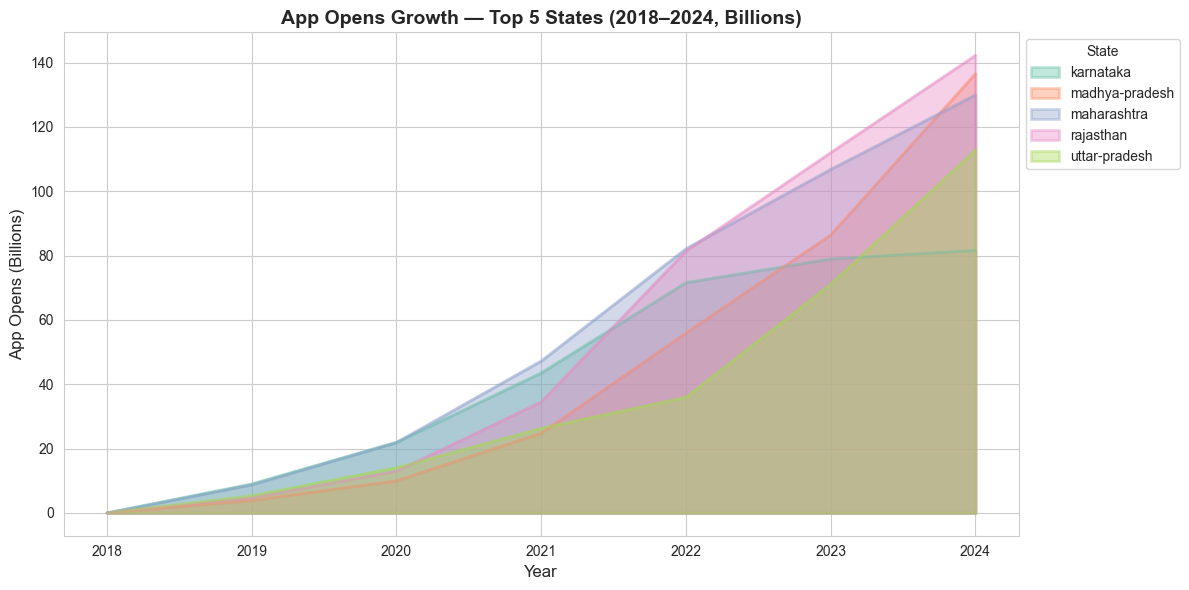

In [31]:
# Chart 18 — Area chart: App opens growth over years by top 5 states
top5_user_states = agg_user.groupby('state')['app_opens'].sum().nlargest(5).index.tolist()
user_year_state = agg_user[agg_user['state'].isin(top5_user_states)].groupby(['year', 'state'])['app_opens'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
user_year_state.div(1e9).plot(kind='area', stacked=False, ax=ax, alpha=0.4, linewidth=2)
ax.set_title('App Opens Growth — Top 5 States (2018–2024, Billions)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('App Opens (Billions)')
ax.legend(title='State', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('chart18.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

An area chart shows both trend and magnitude of multiple lines simultaneously. It's ideal for tracking growth of multiple states over time.

##### 2. What is/are the insight(s) found from the chart?

**Rajasthan and Madhya Pradesh** show surprisingly high app opens relative to other states — their users are very active. Maharashtra leads in absolute app opens. All states show steep growth from 2021 onwards.

##### 3. Will the gained insights help creating a positive business impact?

Yes — Rajasthan and MP's high app activity despite not being the largest economies suggests strong rural and semi-urban adoption. These markets could be key growth drivers for PhonePe's financial services expansion.

#### Chart - 19

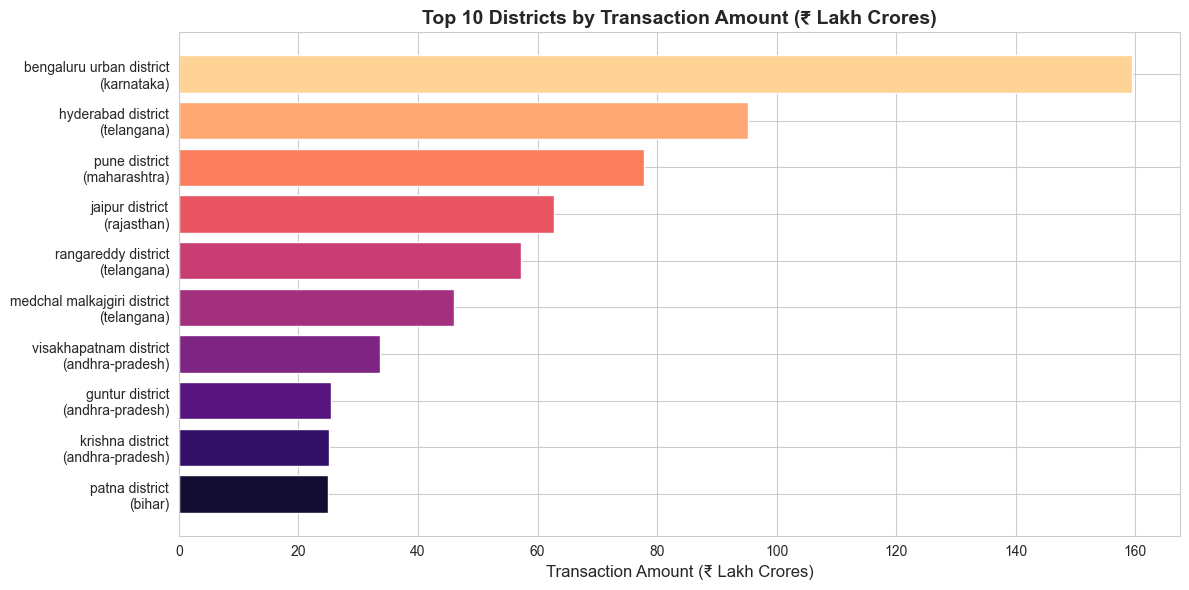

In [32]:
# Chart 19 — Top 10 districts by transaction amount
dist_txn = map_txn.groupby(['state', 'district']).agg(
    total_count=('transaction_count', 'sum'),
    total_amount=('amount_cr', 'sum')
).reset_index().sort_values('total_amount', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{row['district']}\n({row['state']})" for _, row in dist_txn.iterrows()]
bars = ax.barh(labels, dist_txn['total_amount'] / 1e5, color=sns.color_palette("magma_r", 10))
ax.set_title('Top 10 Districts by Transaction Amount (₹ Lakh Crores)', fontweight='bold')
ax.set_xlabel('Transaction Amount (₹ Lakh Crores)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart19.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart with state+district labels gives precise geographic granularity. It shows which specific districts drive the most value.

##### 2. What is/are the insight(s) found from the chart?

**Bengaluru Urban (Karnataka)** is the single largest district by a massive margin — nearly 2x the second place (Hyderabad). The top 10 is dominated by metro districts from 6 states, confirming urban concentration of high-value transactions.

##### 3. Will the gained insights help creating a positive business impact?

Yes — metro districts need premium infrastructure (dedicated support, enterprise merchant deals). The absence of non-metro districts in the top 10 signals that tier-2/3 city growth is the next frontier for expansion.

#### Chart - 20

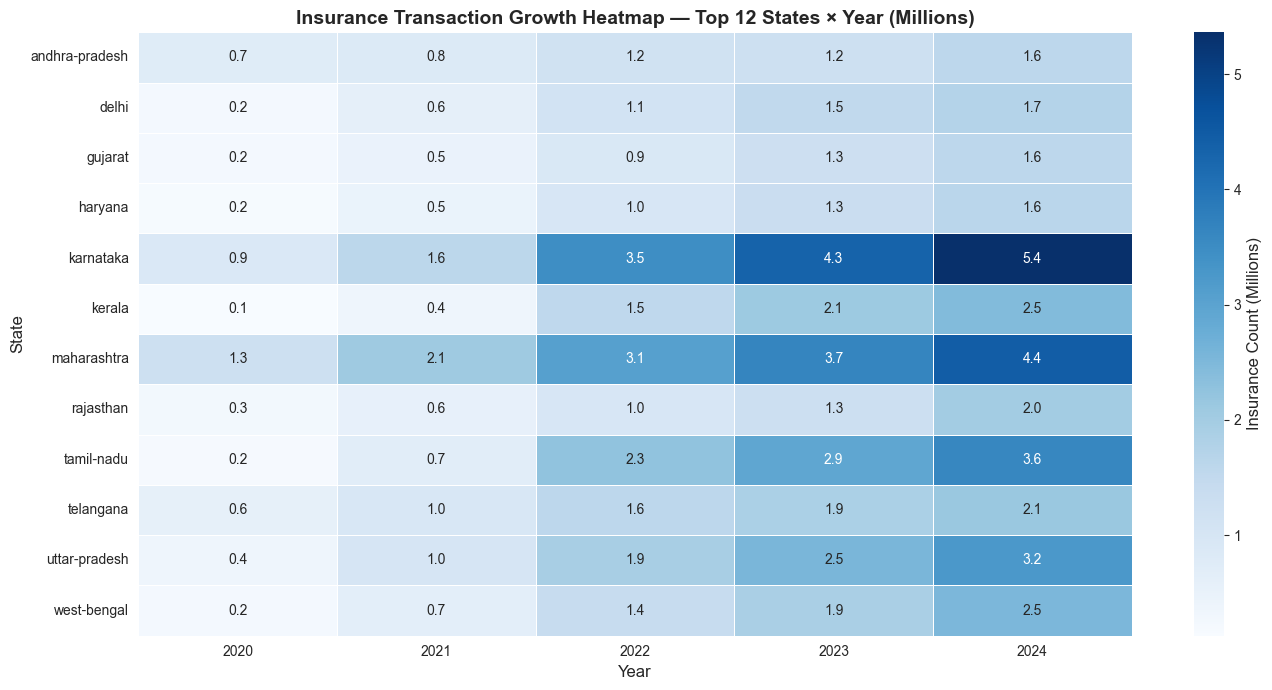

In [33]:
# Chart 20 — Insurance growth heatmap: State vs Year
top_ins_states = agg_ins.groupby('state')['insurance_count'].sum().nlargest(12).index.tolist()
ins_pivot = agg_ins[agg_ins['state'].isin(top_ins_states)].groupby(['state', 'year'])['insurance_count'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(ins_pivot / 1e6, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Insurance Count (Millions)'})
ax.set_title('Insurance Transaction Growth Heatmap — Top 12 States × Year (Millions)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('chart20.png', dpi=100, bbox_inches='tight')
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap for insurance shows adoption trends across states and years, revealing both geographic and temporal patterns simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Insurance transactions were nearly zero before 2021 across all states — this is a **very new product** for PhonePe. Growth accelerated sharply from 2022 onwards, led by Rajasthan, Maharashtra, and Karnataka. Many states still show very low numbers in 2020.

##### 3. Will the gained insights help creating a positive business impact?

Yes — insurance is in the early-growth phase for PhonePe. States that adopted late (northeastern states, Jammu & Kashmir) represent massive untapped potential. Since the product is relatively new everywhere, early mover investments in underserved states could establish strong market share before competition intensifies.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective?


Based on the EDA findings, here are actionable recommendations for PhonePe:

**1. Geographic Expansion:**
- Focus marketing investment on **Lakshadweep, Mizoram, Nagaland, and Ladakh** — these have the lowest absolute transactions but impressive growth rates, signaling early-adopter markets
- Deploy dedicated merchant acquisition teams in **tier-2/3 cities** since metro districts already dominate the top 10

**2. Product Strategy:**
- **Merchant Payments** dominate volume but have low average value (₹501) — introduce loyalty programs and merchant EMI options to increase per-transaction value
- **Peer-to-peer payments** carry the highest value (₹3,134 avg) — offer investment products and savings features immediately after large P2P transfers to capture intent

**3. User Re-engagement:**
- **Delhi and West Bengal** have large user bases but low engagement rates — targeted push notification campaigns and personalized offers can reactivate dormant users
- **Meghalaya and Arunachal Pradesh** have the highest engagement rates despite small user bases — study their usage patterns and replicate in similar demographics

**4. Insurance Growth:**
- Insurance is in early-growth phase (post-2021) — launch **vernacular language insurance education campaigns** in northeastern states and J&K
- Partner with regional insurers for state-specific micro-insurance products (crop insurance in agricultural states, health insurance in urban metros)

**5. Seasonal Strategy:**
- **Q4 is consistently the highest quarter** — plan major product launches, cashback campaigns, and merchant offers to coincide with the festive season
- Address Q1 dip with New Year financial planning campaigns (SIPs, insurance renewals)


# **Conclusion**


This EDA on the PhonePe Pulse dataset revealed several important patterns:

1. **Explosive Growth:** PhonePe transactions grew 210x from 2018 to 2024, confirming India's rapid digital payment adoption
2. **Market Concentration:** A handful of states (Karnataka, Maharashtra, Telangana) contribute disproportionately to transaction volume and value
3. **Category Dynamics:** Merchant Payments dominate in volume while Peer-to-peer dominates in value — two distinct user behaviors requiring different strategies
4. **User Engagement:** Small northeastern states show surprisingly high engagement rates, while large metro-heavy states show relatively lower rates per user
5. **Insurance Opportunity:** Insurance is nascent on PhonePe — massive growth potential exists especially in underserved states
6. **COVID-19 Impact:** A visible dip in 2020 Q2 followed by accelerated growth confirms that the pandemic was a catalyst for digital payment adoption in India

The data clearly demonstrates that PhonePe has successfully established itself in metro and high-population states. The next growth phase will come from geographic deepening (tier-2/3 cities), product diversification (insurance, investments), and re-engaging dormant users in large-user-base states.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***